In [7]:
# Importing the Libraries
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler,LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.initializers import GlorotUniform, HeNormal
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib import pyplot

# load the dataset
data = pd.read_excel('BBDM Project for 2nd research article.xlsx')

# Columns to exclude
columns_to_exclude = ['Chainage', 'Formation','RMC']

# Prepare Features and Target
X = data.drop(['PRnet'] + columns_to_exclude, axis=1)
Y = data['PRnet']

# Label encoding for multiple columns
label_encoder = LabelEncoder()
for col in ['Lithology', 'Weathering', 'Rock Strength']:
    X[col] = label_encoder.fit_transform(X[col])

In [9]:
# Split the data into training, validation, and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Data Standardization
scaler = RobustScaler()
scaler.fit(X_train)  # Fit on the training data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Define the optimal model based on the best hyperparameters found
def create_optimal_model():
    model = Sequential([
        Dense(units=352, activation='relu', kernel_initializer='glorot_uniform', input_shape=(X_train.shape[1],)),
        Dense(units=1, activation='relu', kernel_initializer='he_normal')
    ])
    adam_optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=adam_optimizer,
                  loss='mean_absolute_error',  # Use Mean Absolute Error as the loss function
                  metrics=['mean_absolute_error', 'mean_squared_error'])
    return model


# Create the model
optimal_model = create_optimal_model()

# Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10)

# Train the model
history = optimal_model.fit(X_train_scaled, Y_train, epochs=100, batch_size=32,
                            validation_data=(X_test_scaled, Y_test),
                            callbacks=[early_stopping])

# Evaluate the model
test_loss = optimal_model.evaluate(X_test_scaled, Y_test)
print(f"Final test loss: {test_loss}")

# Predictions
Y_train_pred = optimal_model.predict(X_train_scaled).flatten()
Y_test_pred = optimal_model.predict(X_test_scaled).flatten()

Epoch 1/100
216/216 [==============================] - 1s 2ms/step - loss: 51.0440 - mean_absolute_error: 51.0440 - mean_squared_error: 3120.2537 - val_loss: 23.9072 - val_mean_absolute_error: 23.9072 - val_mean_squared_error: 872.5263
Epoch 2/100
216/216 [==============================] - 0s 1ms/step - loss: 16.0928 - mean_absolute_error: 16.0928 - mean_squared_error: 445.3409 - val_loss: 10.0789 - val_mean_absolute_error: 10.0789 - val_mean_squared_error: 176.6878
Epoch 3/100
216/216 [==============================] - 0s 1ms/step - loss: 7.7429 - mean_absolute_error: 7.7429 - mean_squared_error: 112.1739 - val_loss: 5.5258 - val_mean_absolute_error: 5.5258 - val_mean_squared_error: 59.9651
Epoch 4/100
216/216 [==============================] - 0s 1ms/step - loss: 4.4496 - mean_absolute_error: 4.4496 - mean_squared_error: 42.7575 - val_loss: 3.5262 - val_mean_absolute_error: 3.5262 - val_mean_squared_error: 26.9891
Epoch 5/100
216/216 [==============================] - 0s 1ms/step - l

In [13]:
# Train metrics
r2_train = r2_score(Y_train, Y_train_pred)
mae_train = mean_absolute_error(Y_train, Y_train_pred)
mse_train = mean_squared_error(Y_train, Y_train_pred)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((Y_train - Y_train_pred) / Y_train)) * 100

# Test metrics
r2_test = r2_score(Y_test, Y_test_pred)
mae_test = mean_absolute_error(Y_test, Y_test_pred)
mse_test = mean_squared_error(Y_test, Y_test_pred)
rmse_test = np.sqrt(mse_test)
mape_test = np.mean(np.abs((Y_test - Y_test_pred) / Y_test)) * 100

# Pearson correlation
pearson_corr, _ = pearsonr(Y_test, Y_test_pred)
print(f"Pearson Correlation (Test): {pearson_corr:.3f}")

# Combine metrics into a DataFrame
metrics_df = pd.DataFrame({
    'Metric': ['R2', 'MAE', 'RMSE', 'MAPE'],
    'Train': [r2_train, mae_train, rmse_train, mape_train],
    'Test': [r2_test, mae_test, rmse_test, mape_test]
})
metrics_df[['Train', 'Test']] = metrics_df[['Train', 'Test']].round(3)
print(metrics_df)

Pearson Correlation (Test): 0.966
  Metric  Train   Test
0     R2  0.912  0.933
1    MAE  2.253  2.201
2   RMSE  4.589  4.078
3   MAPE  3.451  3.424


54/54 [==============================] - 0s 623us/step


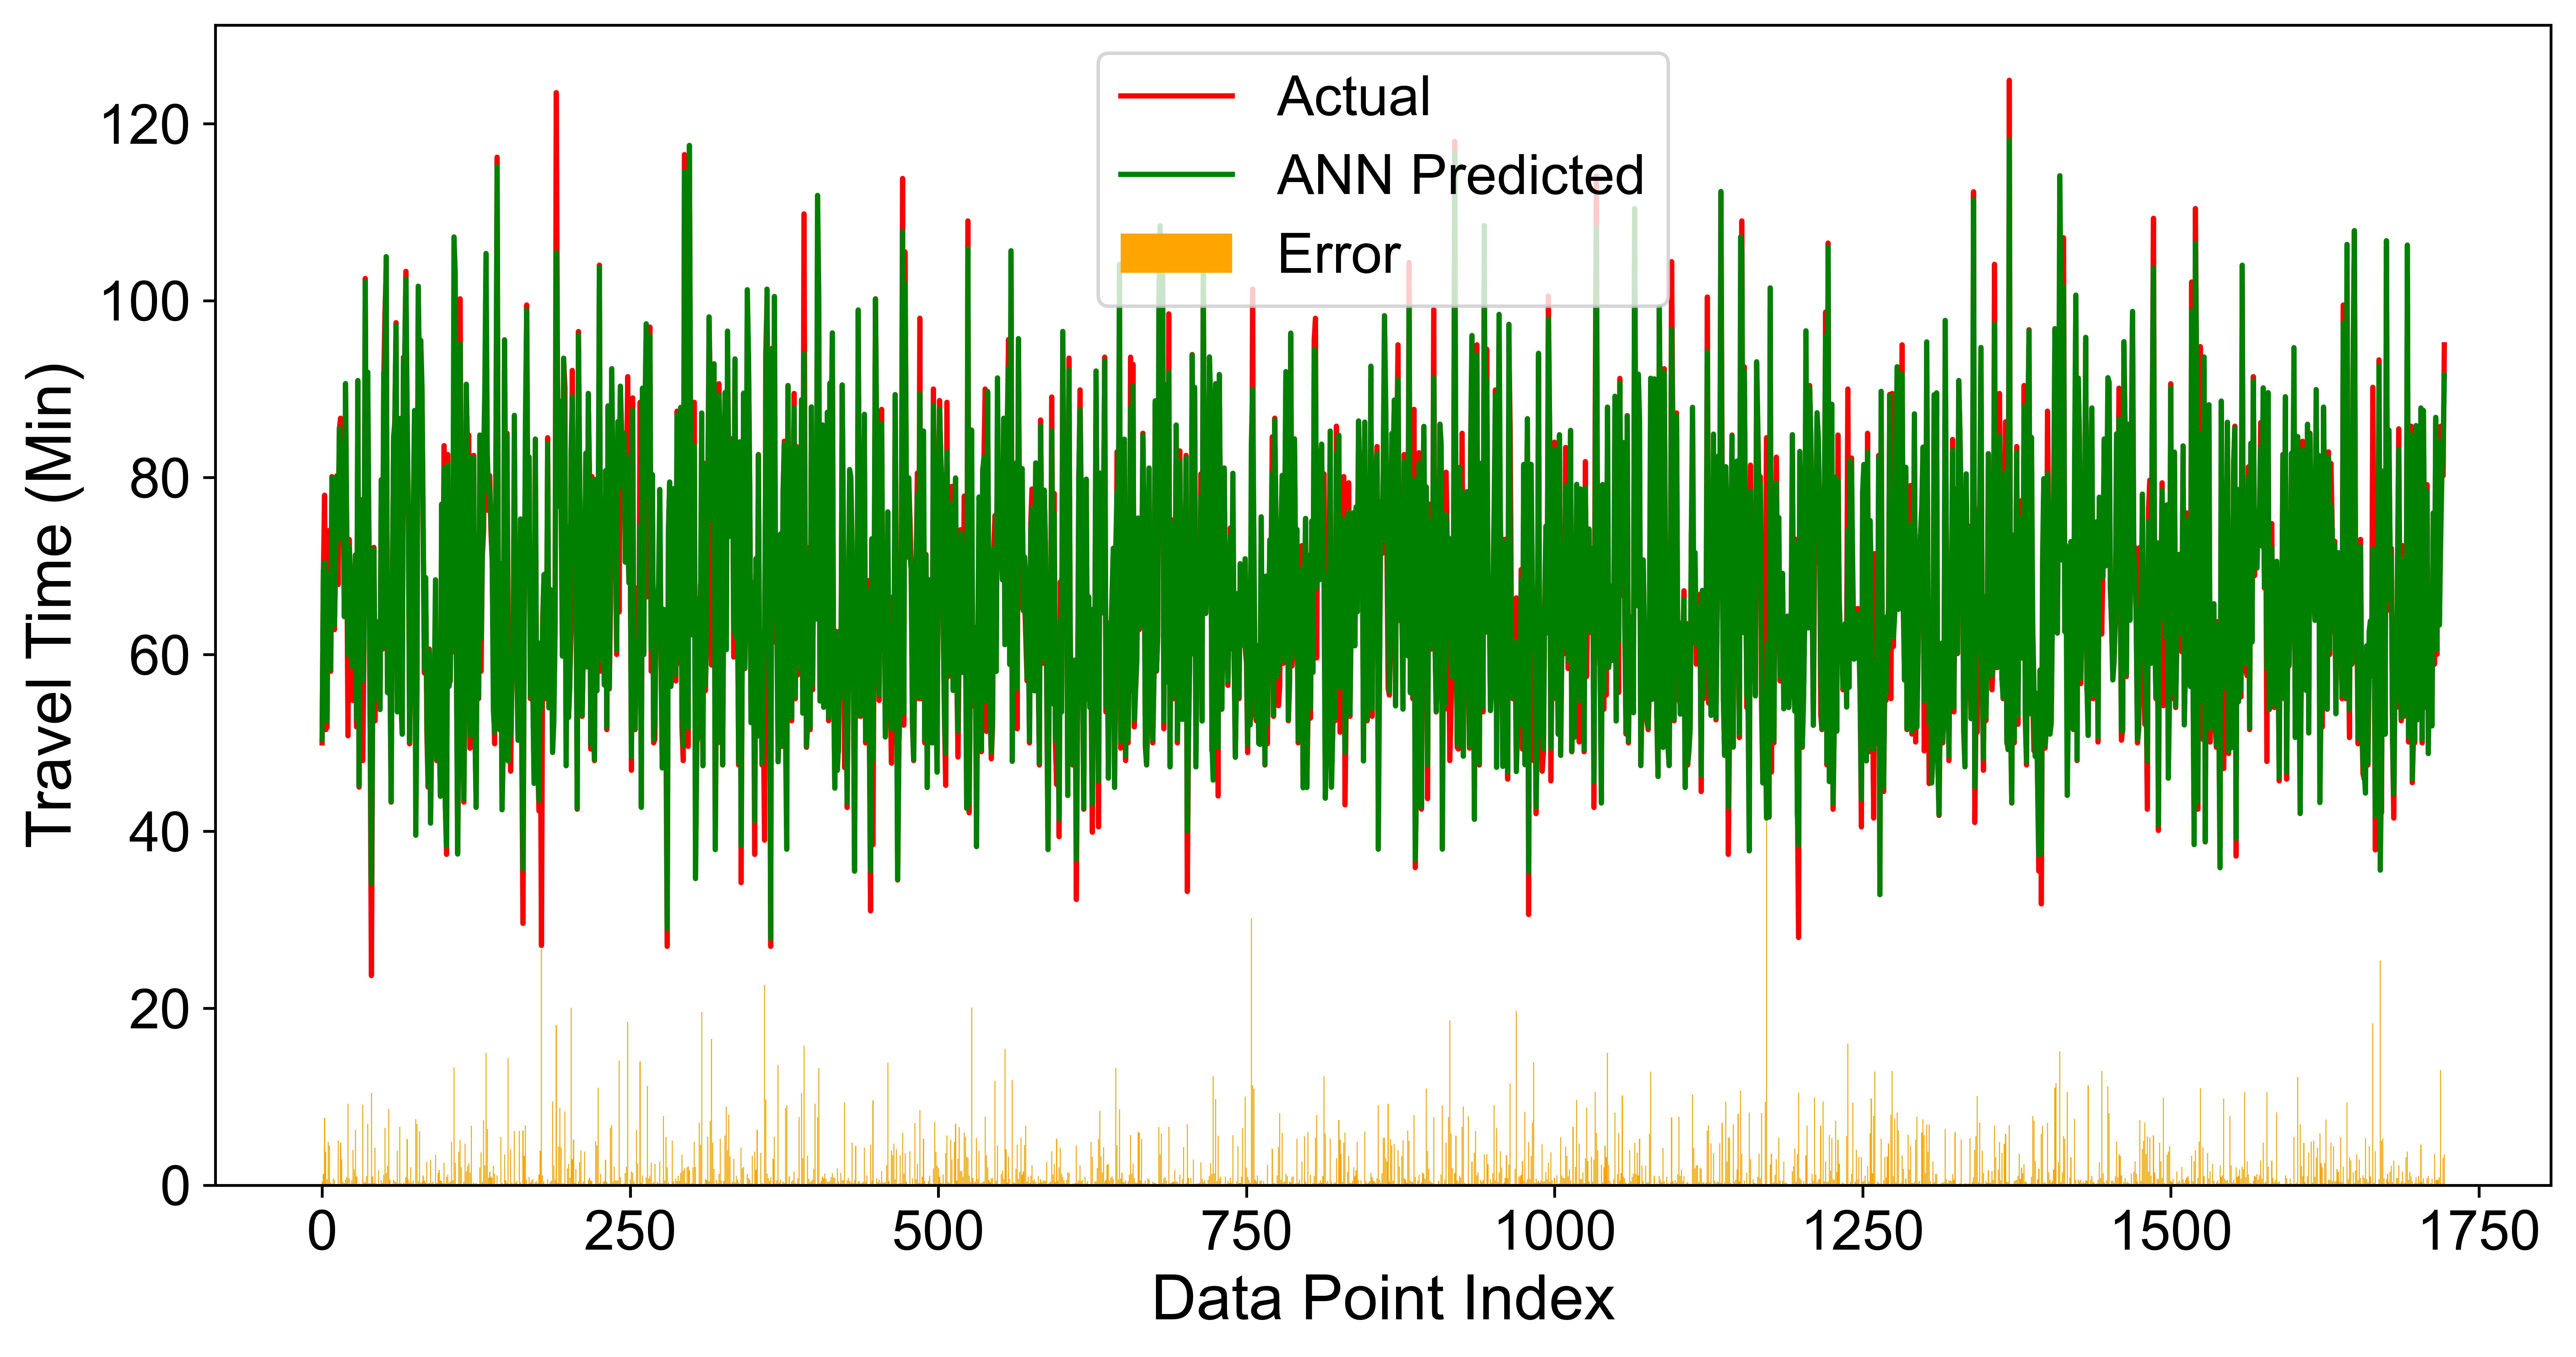

In [15]:
# Predictions
predictions = optimal_model.predict(X_test_scaled).flatten()
# Visualize actual vs. predicted values
pyplot.rc('font', family='Arial')
plt.figure(figsize=(12, 6), dpi=800)
data_indices = range(len(Y_test))
plt.plot(data_indices, Y_test, 'red', label='Actual')
plt.plot(data_indices, predictions, 'green', label='ANN Predicted')
plt.bar(data_indices, np.abs(Y_test - predictions), color='orange', label='Error')  # Add error bars
plt.xlabel('Data Point Index', fontsize=18)
plt.ylabel('Travel Time (Min)', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(loc='best', fontsize=16)
plt.show()

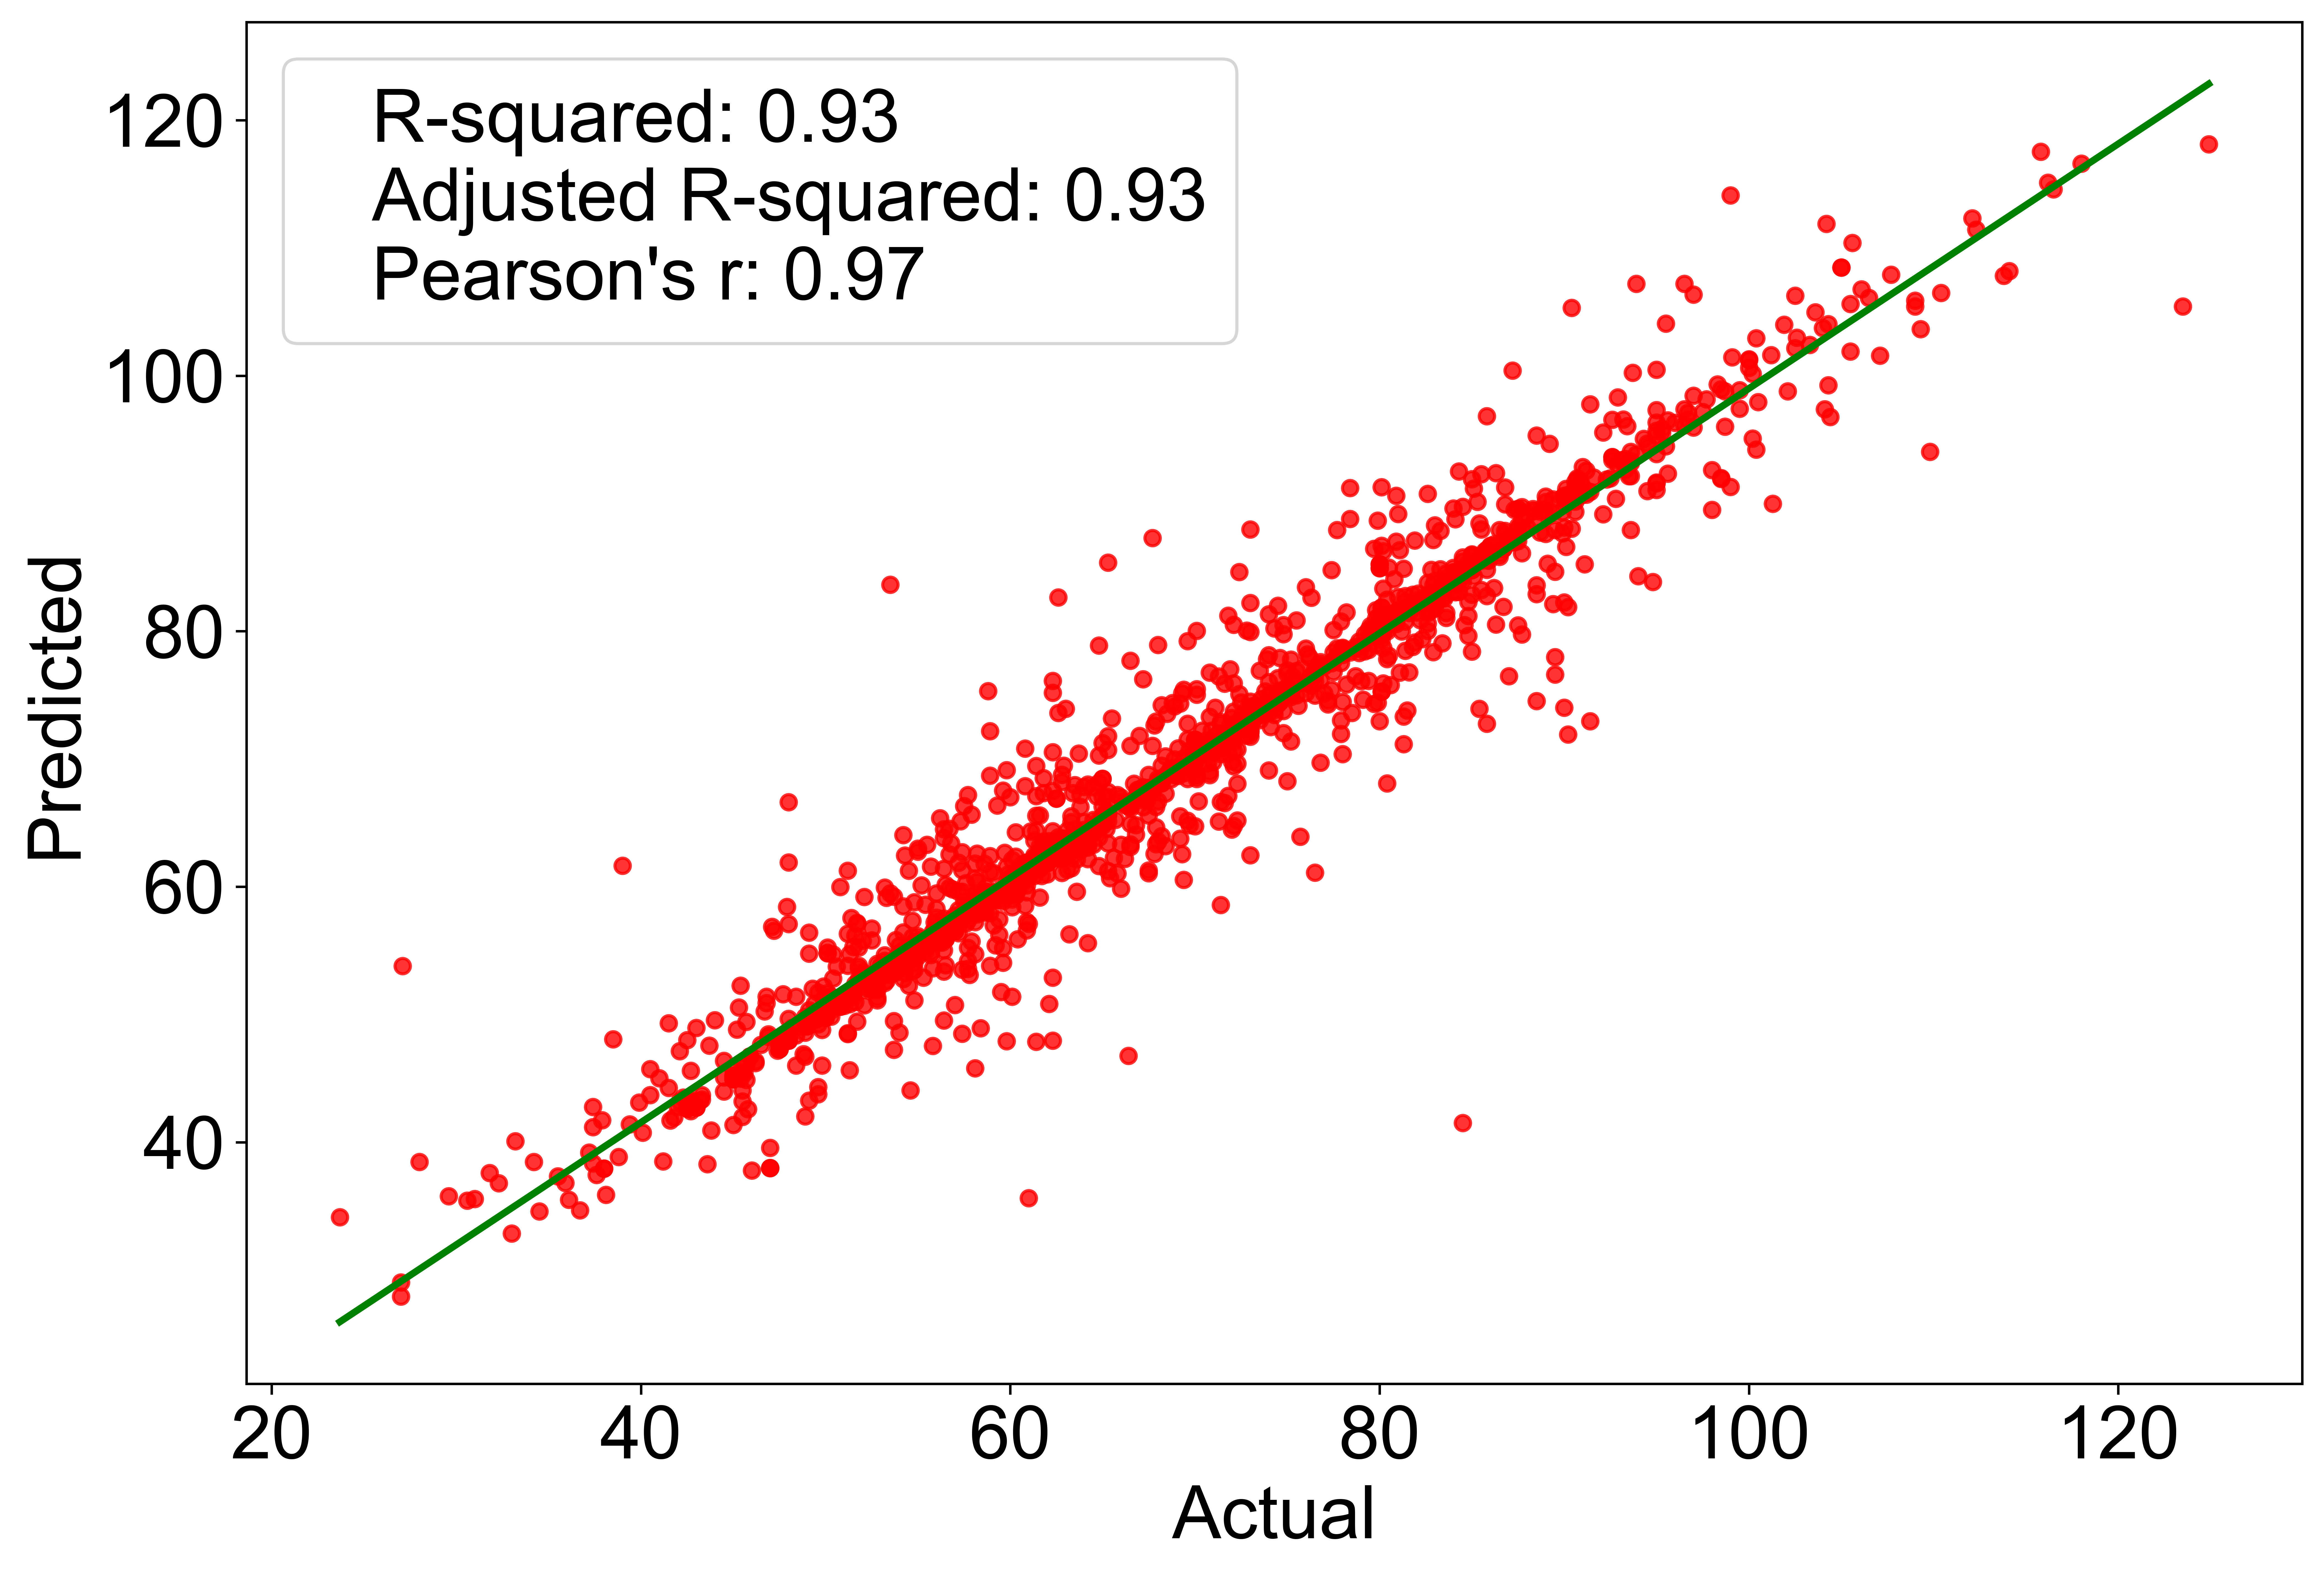

In [17]:
r2 = r2_score(Y_test, predictions)
# Calculate Pearson's correlation coefficient (r)
correlation, _ = pearsonr(Y_test, predictions)

# Calculate the number of predictors (features)
num_predictors = X.shape[1]

# Calculate adjusted R-squared
adjusted_r2 = 1 - (1 - r2) * ((len(Y_test) - 1) / (len(Y_test) - num_predictors - 1))

# Create a scatter plot with linear regression line
plt.figure(figsize=(12, 8), dpi=800)
sns.regplot(x=Y_test, y=predictions, ci=None, scatter_kws={'s': 25, 'color':'red'}, line_kws={'color': 'green'})
plt.xlabel('Actual', fontsize = 24)
plt.ylabel('Predicted', fontsize= 24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
# Add R-squared, adjusted R-squared, and Pearson's r to the upper-left corner of the plot
legend_text = f'R-squared: {r2:.2f}\nAdjusted R-squared: {adjusted_r2:.2f}\nPearson\'s r: {correlation:.2f}'
plt.legend([legend_text], loc='upper left', fontsize=24, handlelength=0, markerscale=0)

plt.show()

## Loss function evaluation in ANN model_with MAE

Final Training Loss (MAE): 2.240720510482788
Final Validation Loss (MAE): 2.166102886199951


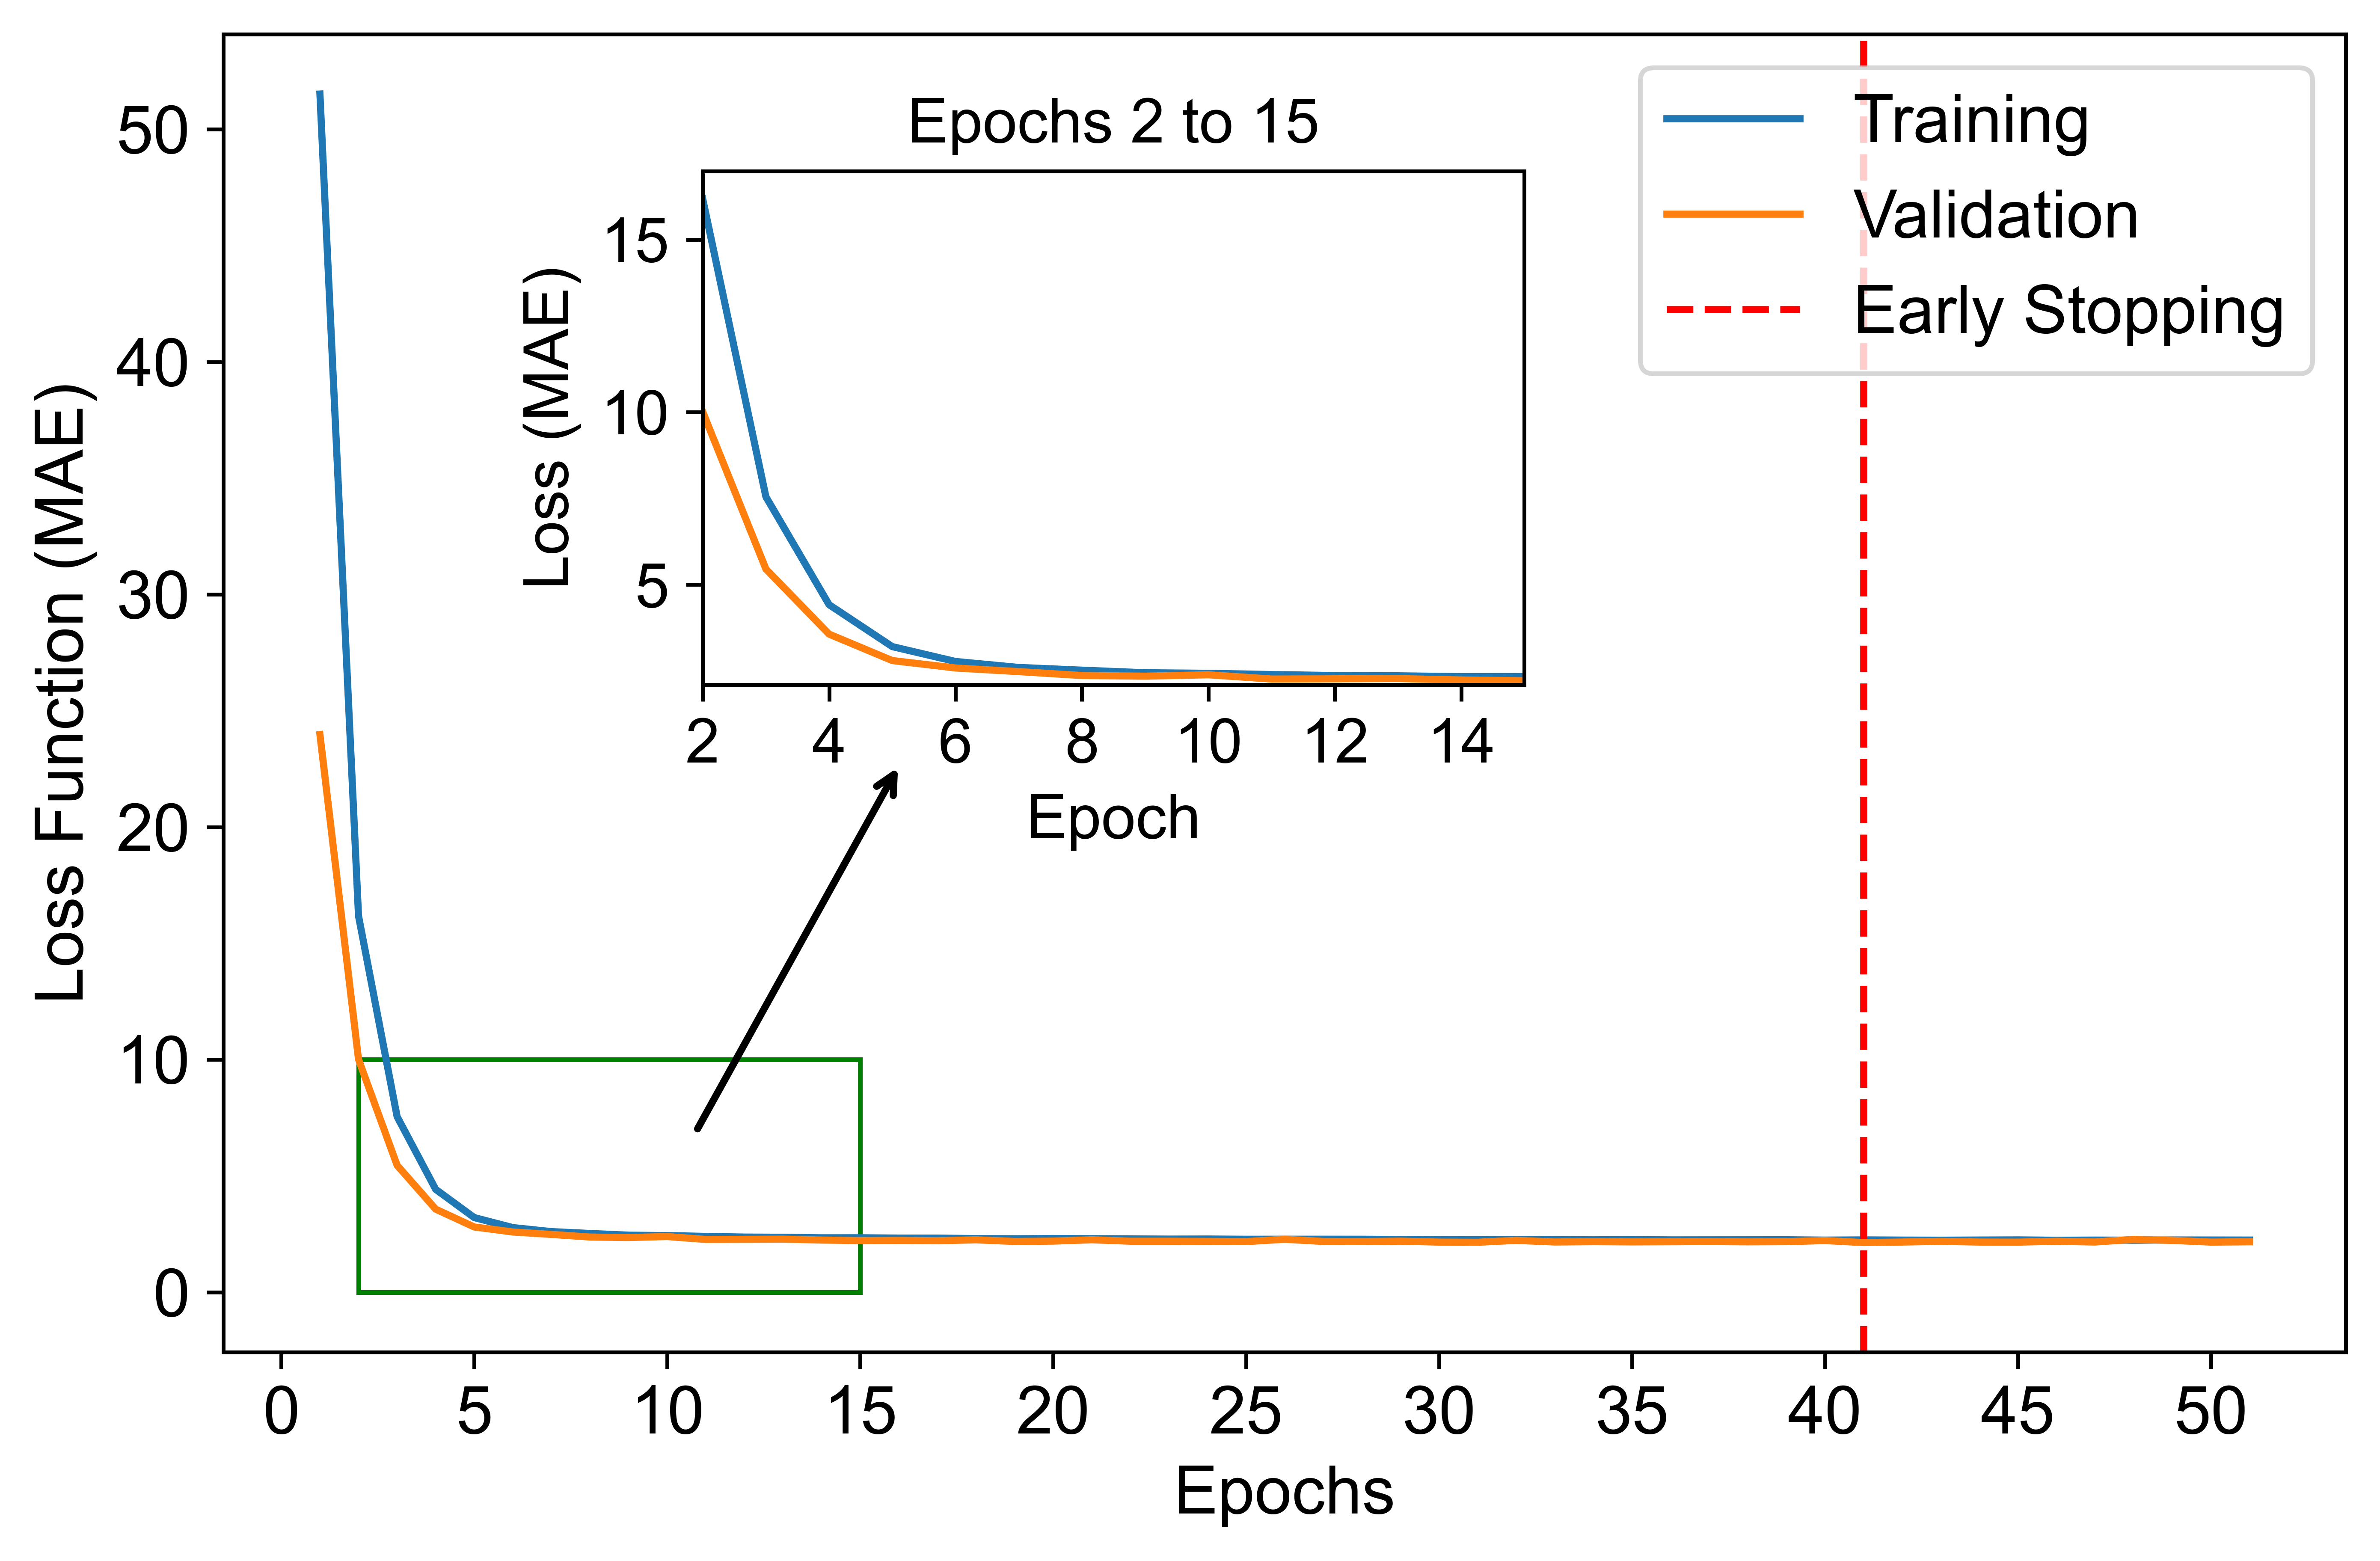

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Assume history is the variable containing the training history
# Using MAE as the loss metric
train_loss = history.history['mean_absolute_error']
val_loss = history.history['val_mean_absolute_error']
epochs = range(1, len(train_loss) + 1)

# Create main plot
fig, ax = plt.subplots(figsize=(8, 5), dpi=800)

# Plot training & validation loss values on main plot
ax.plot(epochs, train_loss, label='Training')
ax.plot(epochs, val_loss, label='Validation')
ax.set_title('', fontsize=14)
ax.set_ylabel('Loss Function (MAE)', fontsize=14)
ax.set_xlabel('Epochs', fontsize=14)
ax.legend(loc='upper right', fontsize=14)

# Set x-axis ticks with interval of 5
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

# Create inset subplot within the main plot
inset_ax = fig.add_subplot(111, position=[0.3, 0.5, 0.3, 0.3])  # [left, bottom, width, height]

# Use epochs[1:16] for epoch 2 to 15 (to match rectangle: 2 to 15)
inset_ax.plot(epochs[1:16], train_loss[1:16], label='Training')
inset_ax.plot(epochs[1:16], val_loss[1:16], label='Validation')
inset_ax.set_title('Epochs 2 to 15', fontsize=13)
inset_ax.set_ylabel('Loss (MAE)', fontsize=13)
inset_ax.set_xlabel('Epoch', fontsize=13)

# Remove legends from inset subplot
inset_ax.legend().set_visible(False)

# Set tick size and limits for both axes
inset_ax.tick_params(axis='x', labelsize=13)
inset_ax.tick_params(axis='y', labelsize=13)
inset_ax.xaxis.set_major_locator(plt.MultipleLocator(2))

# Dynamically set y-limits based on the minimum and maximum MAE values for epochs 2-15
inset_ax.set_ylim([min(min(train_loss[1:16]), min(val_loss[1:16])) * 0.95,
                   max(max(train_loss[1:16]), max(val_loss[1:16])) * 1.05])

# Set x-limits to display epochs 2 to 15
inset_ax.set_xlim([2, 15])

# Define the position of the rectangle based on your custom limits
rect_x = 2
rect_width = 13  # End at epoch 15
rect_y = 0
rect_height = 10

# Add rectangle patch to mark the position of the subplot in the main plot
rect = patches.Rectangle((rect_x, rect_y), rect_width, rect_height,
                         linewidth=1, edgecolor='green', facecolor='none')
ax.add_patch(rect)

# Add arrow with text annotation from rectangle to inset subplot
arrow_props = dict(facecolor='black', arrowstyle='<-', linewidth=1.5)
ax.annotate('', xy=(rect_x + rect_width / 1.5, rect_y + rect_height / 1.5),
            xytext=(0.32, 0.45), textcoords='axes fraction',
            arrowprops=arrow_props)

# Early stopping line
early_stopping_epoch = np.argmin(val_loss) + 1
ax.axvline(x=early_stopping_epoch, color='r', linestyle='--', label='Early Stopping')

# Add Early Stopping legend in the main plot
ax.legend(loc='upper right', fontsize=14)

# Print loss function values
print("Final Training Loss (MAE):", train_loss[-1])
print("Final Validation Loss (MAE):", val_loss[-1])

# Show the plot
plt.show()

## Loss function evaluation in ANN model_With MSE

Final Training Loss (MSE): 21.154415130615234
Final Validation Loss (MSE): 16.632707595825195


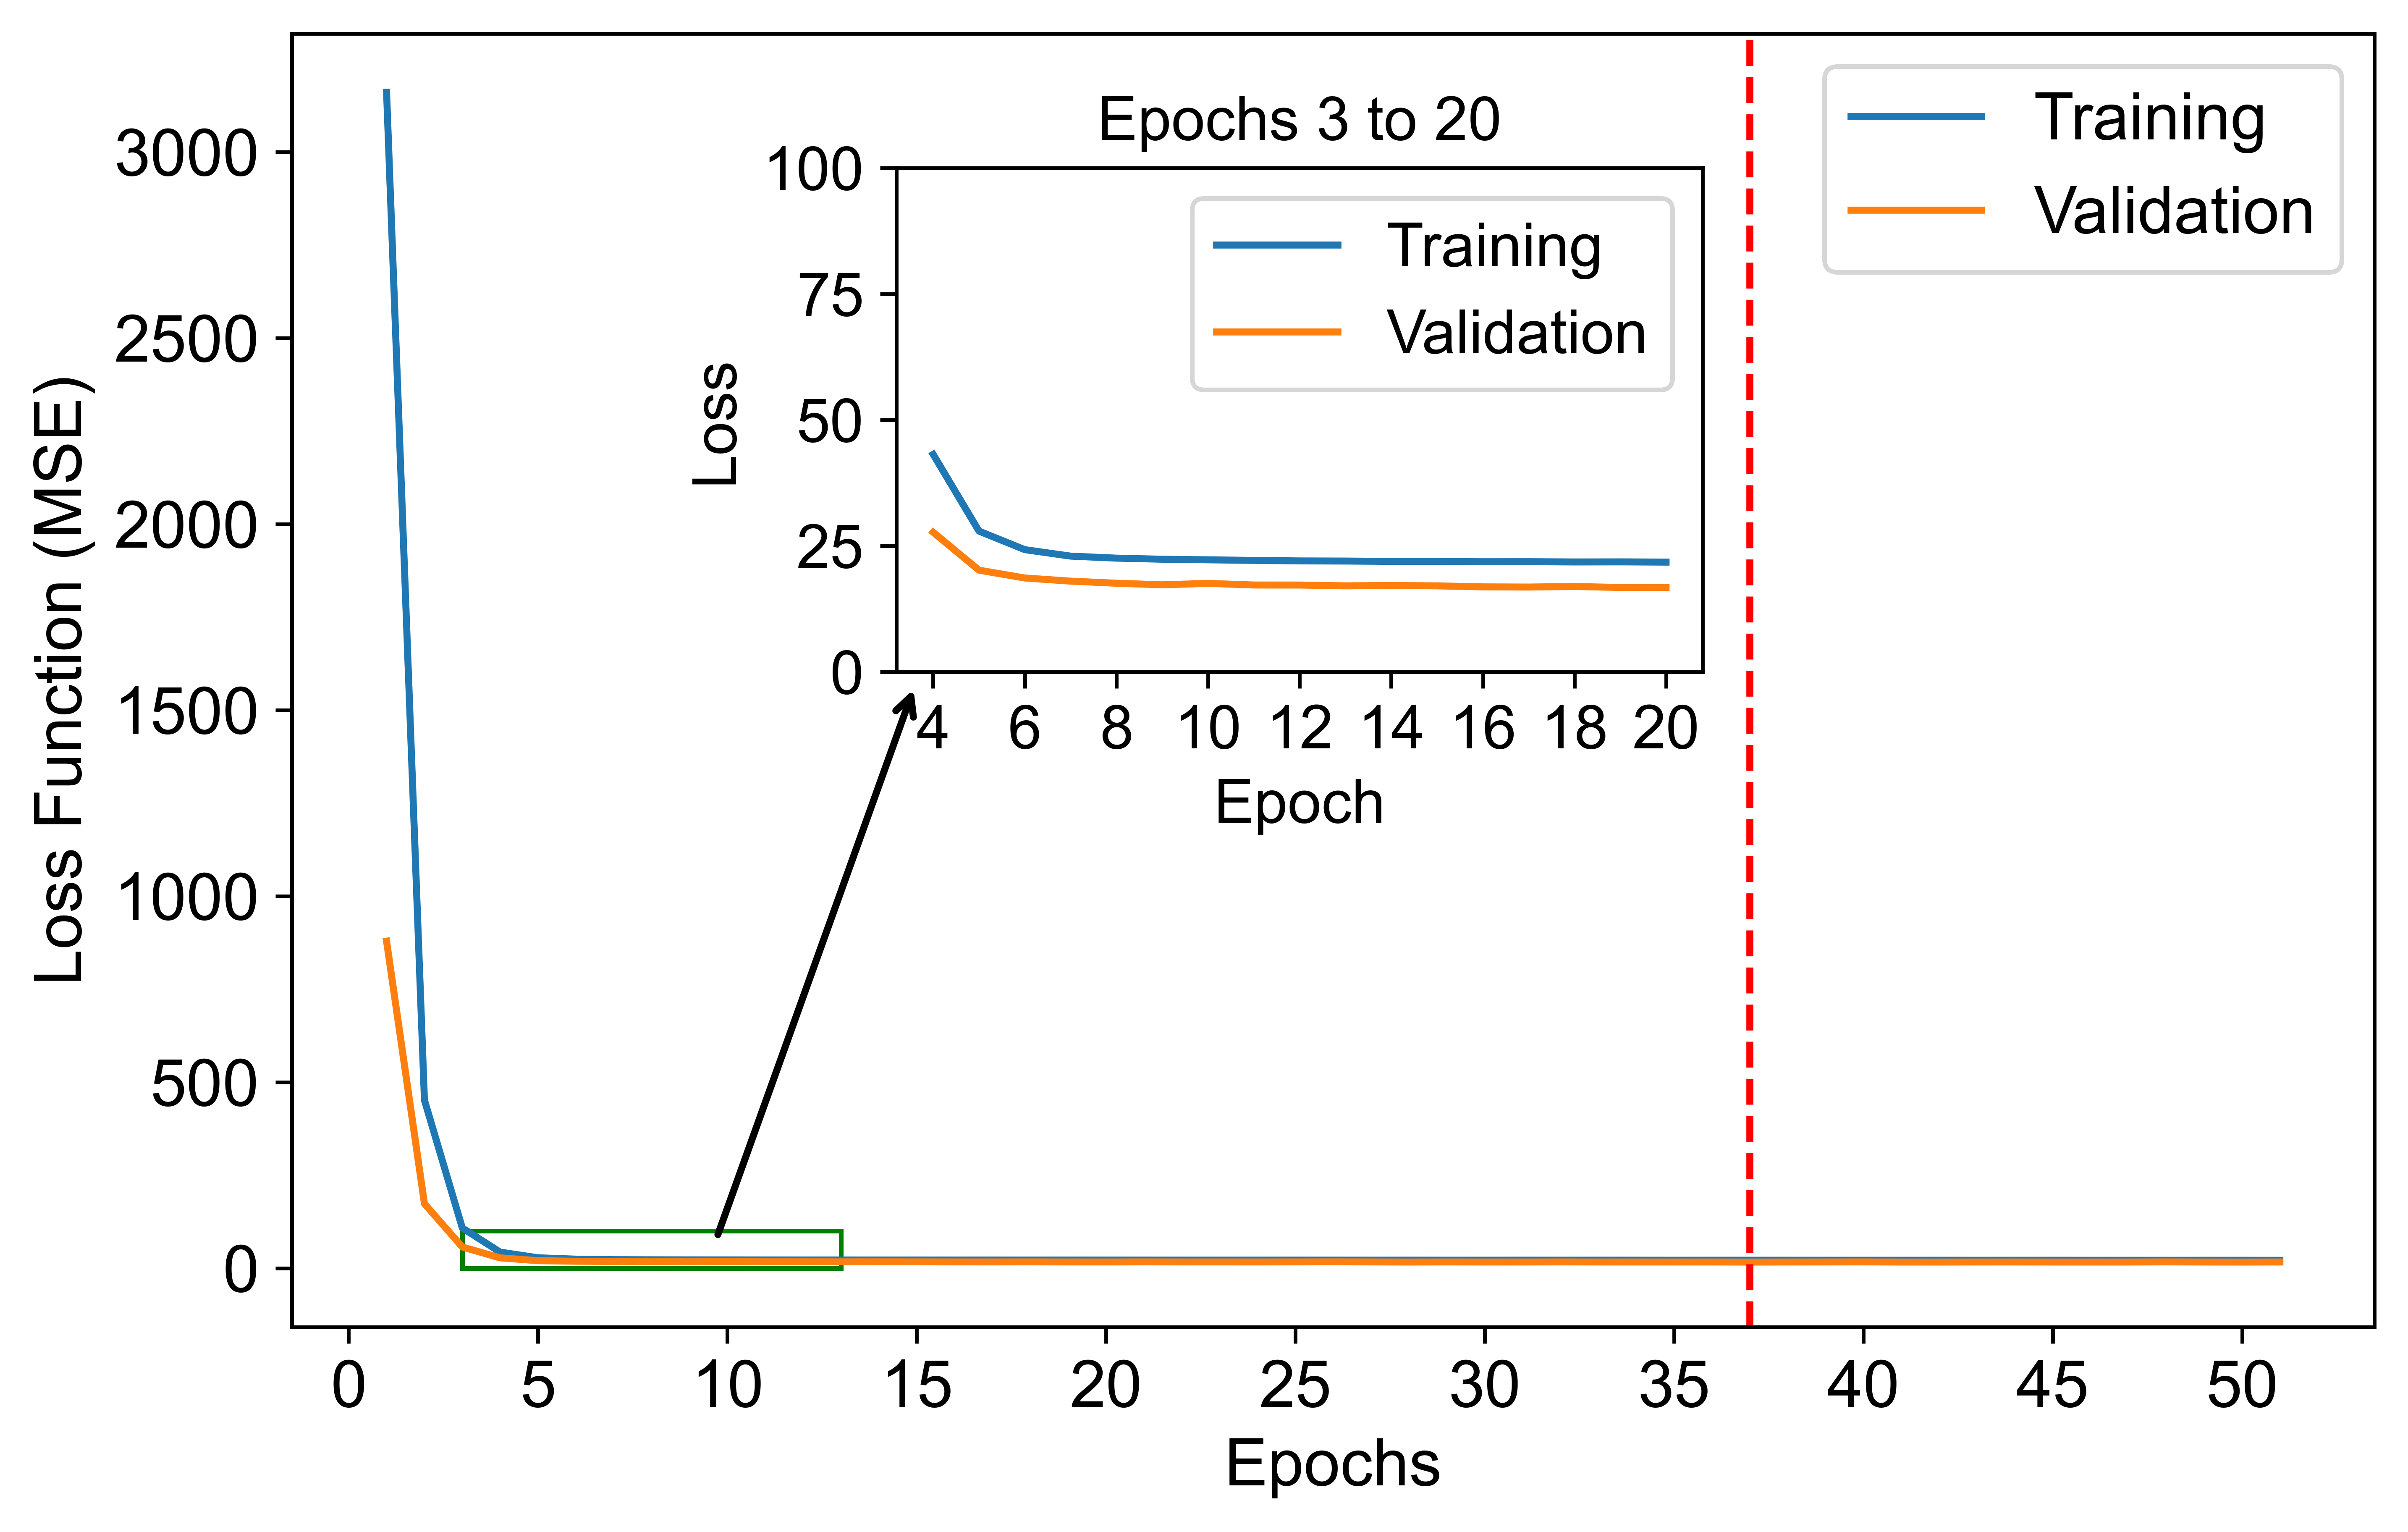

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Assume history is the variable containing the training history
train_loss = history.history['mean_squared_error']
val_loss = history.history['val_mean_squared_error']
epochs = range(1, len(train_loss) + 1)

# Create main plot
fig, ax = plt.subplots(figsize=(8, 5), dpi=800)

# Plot training & validation loss values on main plot
ax.plot(epochs, train_loss, label='Training')
ax.plot(epochs, val_loss, label='Validation')
ax.set_title('', fontsize=14)
ax.set_ylabel('Loss Function (MSE)', fontsize=14)
ax.set_xlabel('Epochs', fontsize=14)
ax.legend(loc='upper right', fontsize=14)

# Set x-axis ticks with interval of 5
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
ax.tick_params(axis='x', labelsize=14)  # Set x-axis tick labels size
ax.tick_params(axis='y', labelsize=14)  # Set y-axis tick labels size

# Create inset subplot within the main plot
inset_ax = fig.add_subplot(111, position=[0.35, 0.5, 0.3, 0.3])  # [left, bottom, width, height]
inset_ax.plot(epochs[3:20], train_loss[3:20], label='Training')
inset_ax.plot(epochs[3:20], val_loss[3:20], label='Validation')
inset_ax.set_title('Epochs 3 to 20', fontsize=13)
inset_ax.set_ylabel('Loss', fontsize=13)
inset_ax.set_xlabel('Epoch', fontsize=13)
inset_ax.legend(loc='upper right', fontsize=13)

# Set tick size for both x and y axes
inset_ax.tick_params(axis='x', labelsize=13)  # Adjust tick size for x-axis
inset_ax.tick_params(axis='y', labelsize=13)  # Adjust tick size for y-axis

# Set x-axis tick interval for inset subplot
inset_ax.xaxis.set_major_locator(plt.MultipleLocator(2))

# Set y-axis limits for the inset subplot to show from 0 to 200
inset_ax.set_ylim([0, 100])

# Define the position of the rectangle based on the inset subplot's x and y axis limits
rect_x = 3 # Start from epoch 3
rect_width = 13 - rect_x  # End at epoch 15

# Rectangle should match the y-axis limits of the inset subplot
rect_y = 0  # Starting y position of the rectangle
rect_height = 100 - rect_y  # Full height to fit within 0 to 200

# Add rectangle patch to mark the position of the subplot in the main plot
rect = patches.Rectangle((rect_x, rect_y), rect_width, rect_height, linewidth=1, edgecolor='green', facecolor='none')
ax.add_patch(rect)

# Add arrow with text annotation from rectangle to inset subplot
arrow_props = dict(facecolor='black', arrowstyle='<-', linewidth=1.5)
ax.annotate('', xy=(rect_x + rect_width / 1.5, rect_y + rect_height / 1.5), xytext=(0.3, 0.5), textcoords='axes fraction',
            arrowprops=arrow_props)

# Early stopping line
early_stopping_epoch = np.argmin(val_loss) + 1
ax.axvline(x=early_stopping_epoch, color='r', linestyle='--', label='Early Stopping')

# Print loss function value
print("Final Training Loss (MSE):", train_loss[-1])
print("Final Validation Loss (MSE):", val_loss[-1])

plt.show()